<a href="https://colab.research.google.com/github/enriquefroes/cfem-mg-analise/blob/main/NB1_Exploracao_Limpeza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
warnings.filterwarnings('ignore')

PASTA = "/content/drive/MyDrive/CFEM Minas Gerais"

os.makedirs(f"{PASTA}/graficos",          exist_ok=True)
os.makedirs(f"{PASTA}/dados_processados", exist_ok=True)

print(f"✅ Drive montado. Pasta de trabalho:")
print(f"   {PASTA}")
print(f"   Arquivos disponíveis: {os.listdir(PASTA)}")


Mounted at /content/drive
✅ Drive montado. Pasta de trabalho:
   /content/drive/MyDrive/CFEM Minas Gerais
   Arquivos disponíveis: ['CFEM_Arrecadacao_2022_2026.csv', 'CFEM_Arrecadacao_2017_2021.xlsx', 'Untitled0.ipynb', 'graficos', 'dados_processados']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("✅ Bibliotecas carregadas.")


✅ Bibliotecas carregadas.


In [ ]:
df_1721 = pd.read_excel(f"{PASTA}/CFEM_Arrecadacao_2017_2021.xlsx")
print(f"2017-2021 → {df_1721.shape[0]:,} linhas | {df_1721.shape[1]} colunas")

df_2226 = pd.read_csv(f"{PASTA}/CFEM_Arrecadacao_2022_2026.csv", encoding='latin1')
print(f"2022-2026 → {df_2226.shape[0]:,} linhas | {df_2226.shape[1]} colunas")

df_1721.head(3)


2017-2021 → 625,460 linhas | 14 colunas
2022-2026 → 584,988 linhas | 14 colunas


,Ano,Mês,Processo,AnoDoProcesso,Tipo_PF_PJ,CPF_CNPJ,Substância,UF,CodigoMunicipio,Município,QuantidadeComercializada,UnidadeDeMedida,ValorRecolhido,DataCriacao
0,2017,1,880107.0,2016.0,PF,***039159**,AREIA,AM,1302603,MANAUS,8240.00,t,660.45,2017-01-02 12:26:00
1,2017,1,810657.0,1970.0,PJ,57240000122,ARGILA,DF,5300108,BRASÍLIA,11018.00,t,243.86,2017-01-02 07:33:00
2,2017,1,900985.0,1982.0,PJ,57240000122,CALCÁRIO,DF,5300108,BRASÍLIA,94813.64,t,18977.92,2017-01-02 07:35:00


In [ ]:
print("=== Colunas ===")
print(df_1721.columns.tolist())

print("\n=== Tipos — 2017-2021 ===")
print(df_1721.dtypes)

print("\n=== Nulos — 2017-2021 ===")
print(df_1721.isnull().sum())

print("\n=== Anos presentes ===")
print("2017-2021:", sorted(df_1721['Ano'].dropna().unique()))
print("2022-2026:", sorted(df_2226['Ano'].dropna().unique()))


=== Colunas ===
['Ano', 'Mês', 'Processo', 'AnoDoProcesso', 'Tipo_PF_PJ', 'CPF_CNPJ', 'Substância', 'UF', 'CodigoMunicipio', 'Município', 'QuantidadeComercializada', 'UnidadeDeMedida', 'ValorRecolhido', 'DataCriacao']

=== Tipos — 2017-2021 ===
Ano                                  int64
Mês                                  int64
Processo                           float64
AnoDoProcesso                      float64
Tipo_PF_PJ                          object
CPF_CNPJ                            object
Substância                          object
UF                                  object
CodigoMunicipio                      int64
Município                           object
QuantidadeComercializada           float64
UnidadeDeMedida                     object
ValorRecolhido                     float64
DataCriacao                 datetime64[ns]
dtype: object

=== Nulos — 2017-2021 ===
Ano                            0
Mês                            0
Processo                    9074
AnoDoProcesso

In [ ]:
def limpar_cfem(df, label):

    df = df.copy()


    df['ValorRecolhido'] = (
        df['ValorRecolhido'].astype(str)
        .str.replace(',', '.', regex=False).str.strip()
    )
    df['ValorRecolhido'] = pd.to_numeric(df['ValorRecolhido'], errors='coerce')

    antes = len(df)
    df = df.dropna(subset=['ValorRecolhido', 'Município', 'UF'])
    df = df[df['ValorRecolhido'] > 0]
    print(f"[{label}] Removidas: {antes - len(df):,} linhas → {len(df):,} restantes")

    df['Município']  = df['Município'].str.strip().str.upper()
    df['UF']         = df['UF'].str.strip().str.upper()
    df['Substância'] = df['Substância'].str.strip().str.upper()
    df['Ano']        = df['Ano'].astype(int)
    df['Mês']        = df['Mês'].astype(int)
    return df

df_1721c = limpar_cfem(df_1721, '2017-2021')
df_2226c = limpar_cfem(df_2226, '2022-2026')


[2017-2021] Removidas: 220 linhas → 625,240 restantes
[2022-2026] Removidas: 41 linhas → 584,947 restantes


In [ ]:
df_total = pd.concat([df_1721c, df_2226c], ignore_index=True)
df_total['Periodo'] = df_total['Ano'].apply(
    lambda x: '2017-2021' if x <= 2021 else '2022-2026'
)

print(f"Total consolidado : {len(df_total):,} registros")
print(f"Período coberto   : {df_total['Ano'].min()} – {df_total['Ano'].max()}")
print(f"UFs distintas     : {df_total['UF'].nunique()}")
print(f"Municípios únicos : {df_total['Município'].nunique():,}")
print(f"Substâncias únicas: {df_total['Substância'].nunique()}")
df_total.head()


Total consolidado : 1,210,187 registros
Período coberto   : 2017 – 2026
UFs distintas     : 27
Municípios únicos : 3,389
Substâncias únicas: 220


,Ano,Mês,Processo,AnoDoProcesso,Tipo_PF_PJ,CPF_CNPJ,Substância,UF,CodigoMunicipio,Município,QuantidadeComercializada,UnidadeDeMedida,ValorRecolhido,DataCriacao,Periodo
0,2017,1,880107.0,2016.0,PF,***039159**,AREIA,AM,1302603,MANAUS,8240.0,t,660.45,2017-01-02 12:26:00,2017-2021
1,2017,1,810657.0,1970.0,PJ,57240000122,ARGILA,DF,5300108,BRASÍLIA,11018.0,t,243.86,2017-01-02 07:33:00,2017-2021
2,2017,1,900985.0,1982.0,PJ,57240000122,CALCÁRIO,DF,5300108,BRASÍLIA,94813.64,t,18977.92,2017-01-02 07:35:00,2017-2021
3,2017,1,900985.0,1982.0,PJ,57240000122,CALCÁRIO,DF,5300108,BRASÍLIA,289691.36,t,60583.31,2017-01-02 07:31:00,2017-2021
4,2017,1,861058.0,2002.0,PJ,57240000122,ARGILA,GO,5208004,FORMOSA,3713.35,t,1416.32,2017-01-02 07:37:00,2017-2021


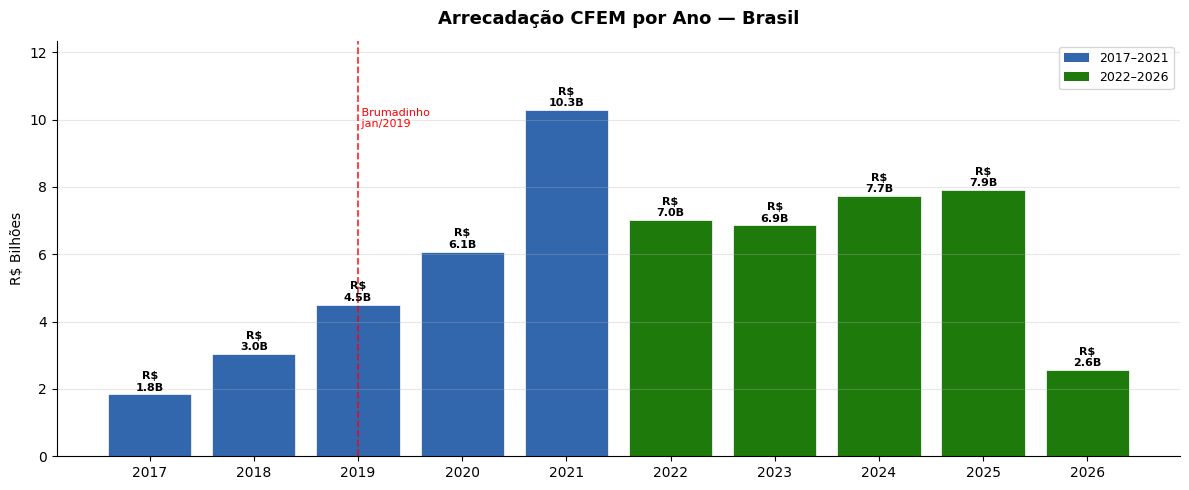

Gráfico salvo no Drive ✅


In [ ]:
por_ano = df_total.groupby('Ano')['ValorRecolhido'].sum().reset_index()
por_ano['Bi'] = por_ano['ValorRecolhido'] / 1e9

fig, ax = plt.subplots(figsize=(12, 5))
cores = ['#3266ad' if a <= 2021 else '#1E7A0A' for a in por_ano['Ano']]
bars  = ax.bar(por_ano['Ano'].astype(str), por_ano['Bi'], color=cores,
               edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, por_ano['Bi']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'R$\n{val:.1f}B', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axvline(x='2019', color='red', linestyle='--', linewidth=1.3, alpha=0.8)
ax.text('2019', por_ano['Bi'].max() * 0.95, ' Brumadinho\n jan/2019',
        color='red', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#3266ad', label='2017–2021'),
    Patch(facecolor='#1E7A0A', label='2022–2026'),
], fontsize=9)

ax.set_title('Arrecadação CFEM por Ano — Brasil', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('R$ Bilhões'); ax.set_ylim(0, por_ano['Bi'].max() * 1.2)
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb1_arrecadacao_anual_brasil.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")


In [ ]:
df_total.to_csv(f"{PASTA}/dados_processados/cfem_consolidado_limpo.csv",
                index=False, encoding='utf-8')

df_mg = df_total[df_total['UF'] == 'MG'].copy()
df_mg.to_csv(f"{PASTA}/dados_processados/cfem_mg_limpo.csv",
             index=False, encoding='utf-8')

print(f"✅ cfem_consolidado_limpo.csv → {len(df_total):,} registros (Brasil)")
print(f"✅ cfem_mg_limpo.csv         → {len(df_mg):,} registros (MG)")
print(f"\nArquivos salvos em: {PASTA}/dados_processados/")


✅ cfem_consolidado_limpo.csv → 1,210,187 registros (Brasil)
✅ cfem_mg_limpo.csv         → 192,898 registros (MG)

Arquivos salvos em: /content/drive/MyDrive/CFEM Minas Gerais/dados_processados/
